## **Comment Category Prediction Challenge**
Predict category assigned to each comment.

Dataset link: https://drive.google.com/drive/folders/19Qh7EruCx64DzI7DAupPb_4J0yWT9sIS?usp=sharing

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [ ]:
# Importing Necessary Libraries

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df_train=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
df_test=pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# Exploratory Data Analysis

In [ ]:
df_train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [ ]:
print(f'The training dataset have {df_train.shape[0]} rows and {df_train.shape[1]} columns')

(198000, 15)

In [ ]:
# Overview of the data

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


## Checking Unique Values

In [ ]:
df_train['race'].unique()

array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
      dtype=object)

In [ ]:
df_train['religion'].unique()

array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
       'hindu', 'buddhist'], dtype=object)

In [ ]:
df_train['gender'].unique()

array([nan, 'none', 'male', 'female', 'transgender', 'other'],
      dtype=object)

### Checking null values in the dataset

In [ ]:
# checking null values in train dataset
print('Null values in train dataset :-')
print(df_train.isna().sum())
print('\n')
print('Null values in test dataset :-')
print(df_test.isna().sum())

Null values in train dataset :-
created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


Null values in test dataset :-
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


### Checking duplicates

In [ ]:
print(f'No. of duplicates in train dataset: ',df_train.duplicated().sum())
print(f'No. of duplicates in test dataset: ',df_test.duplicated().sum())

No. of duplicates in train dataset:  0
No. of duplicates in test dataset:  0


### Checking unique values in each column

In [ ]:
nunique_series = df_train.nunique()
nunique_df = pd.DataFrame({
    'Column': nunique_series.index,
    'Unique Values Count': nunique_series.values
})

nunique_df

,Column,Unique Values Count
0,created_date,197996
1,post_id,52
2,emoticon_1,36
3,emoticon_2,10
4,emoticon_3,16
5,upvote,122
6,downvote,62
7,if_1,57
8,if_2,81
9,race,6


# Data Visualization & Insights

### Target Variable Analysis

In [ ]:
df_train['label'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

print(df_train['label'].value_counts(normalize=True))


**Insights:**

> The dataset is highly imbalanced, with class 0 dominating (~57.6%) followed by class 2 (~31.5%), while classes 1 and 3 are very underrepresented.This imbalance can bias the model toward majority classes, reducing performance on minority classes.


### Numerical Feature Analysis

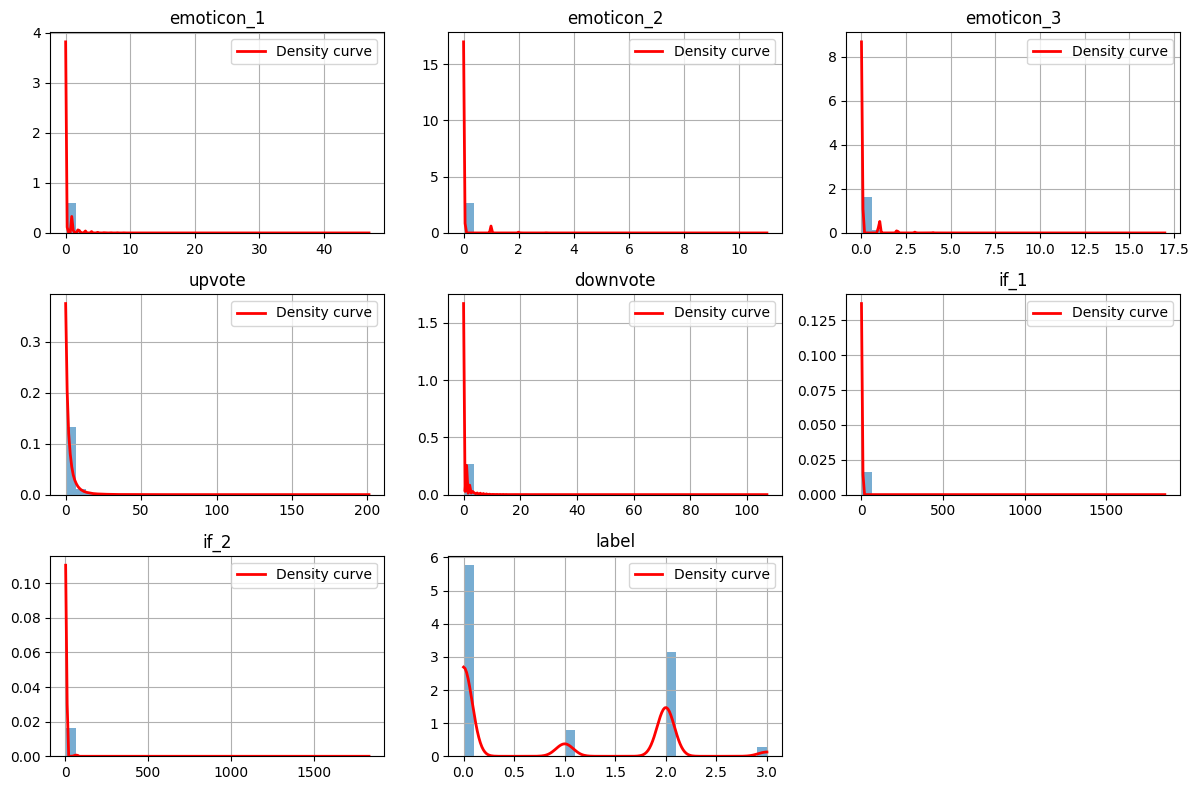

In [ ]:
from scipy.stats import gaussian_kde

exclude_col = 'post_id'

numerical_cols = df_train.select_dtypes(include=['number']).columns
numerical_cols = [col for col in numerical_cols if col != exclude_col]

df_train[numerical_cols].hist(figsize=(12, 8), bins=30, density=True, alpha=0.6)

# Add KDE curves (from previous)
for ax in plt.gcf().axes:
    col_name = ax.get_title()
    if col_name in numerical_cols:
        data = df_train[col_name].dropna()
        if len(data) > 1:
            kde = gaussian_kde(data)
            x_range = np.linspace(data.min(), data.max(), 200)
            ax.plot(x_range, kde(x_range), 'r-', linewidth=2, label='Density curve')
            ax.legend()

plt.tight_layout()
plt.show()


**Insights:**


> Most features (emoticon, upvote, downvote, if_1, if_2) are highly right-skewed, with values concentrated near zero and a few extreme outliers.This indicates the presence of heavy-tailed distributions, which may negatively impact models sensitive to scale.Applying transformations like log scaling or normalization could improve model performance.


### Outliers detection

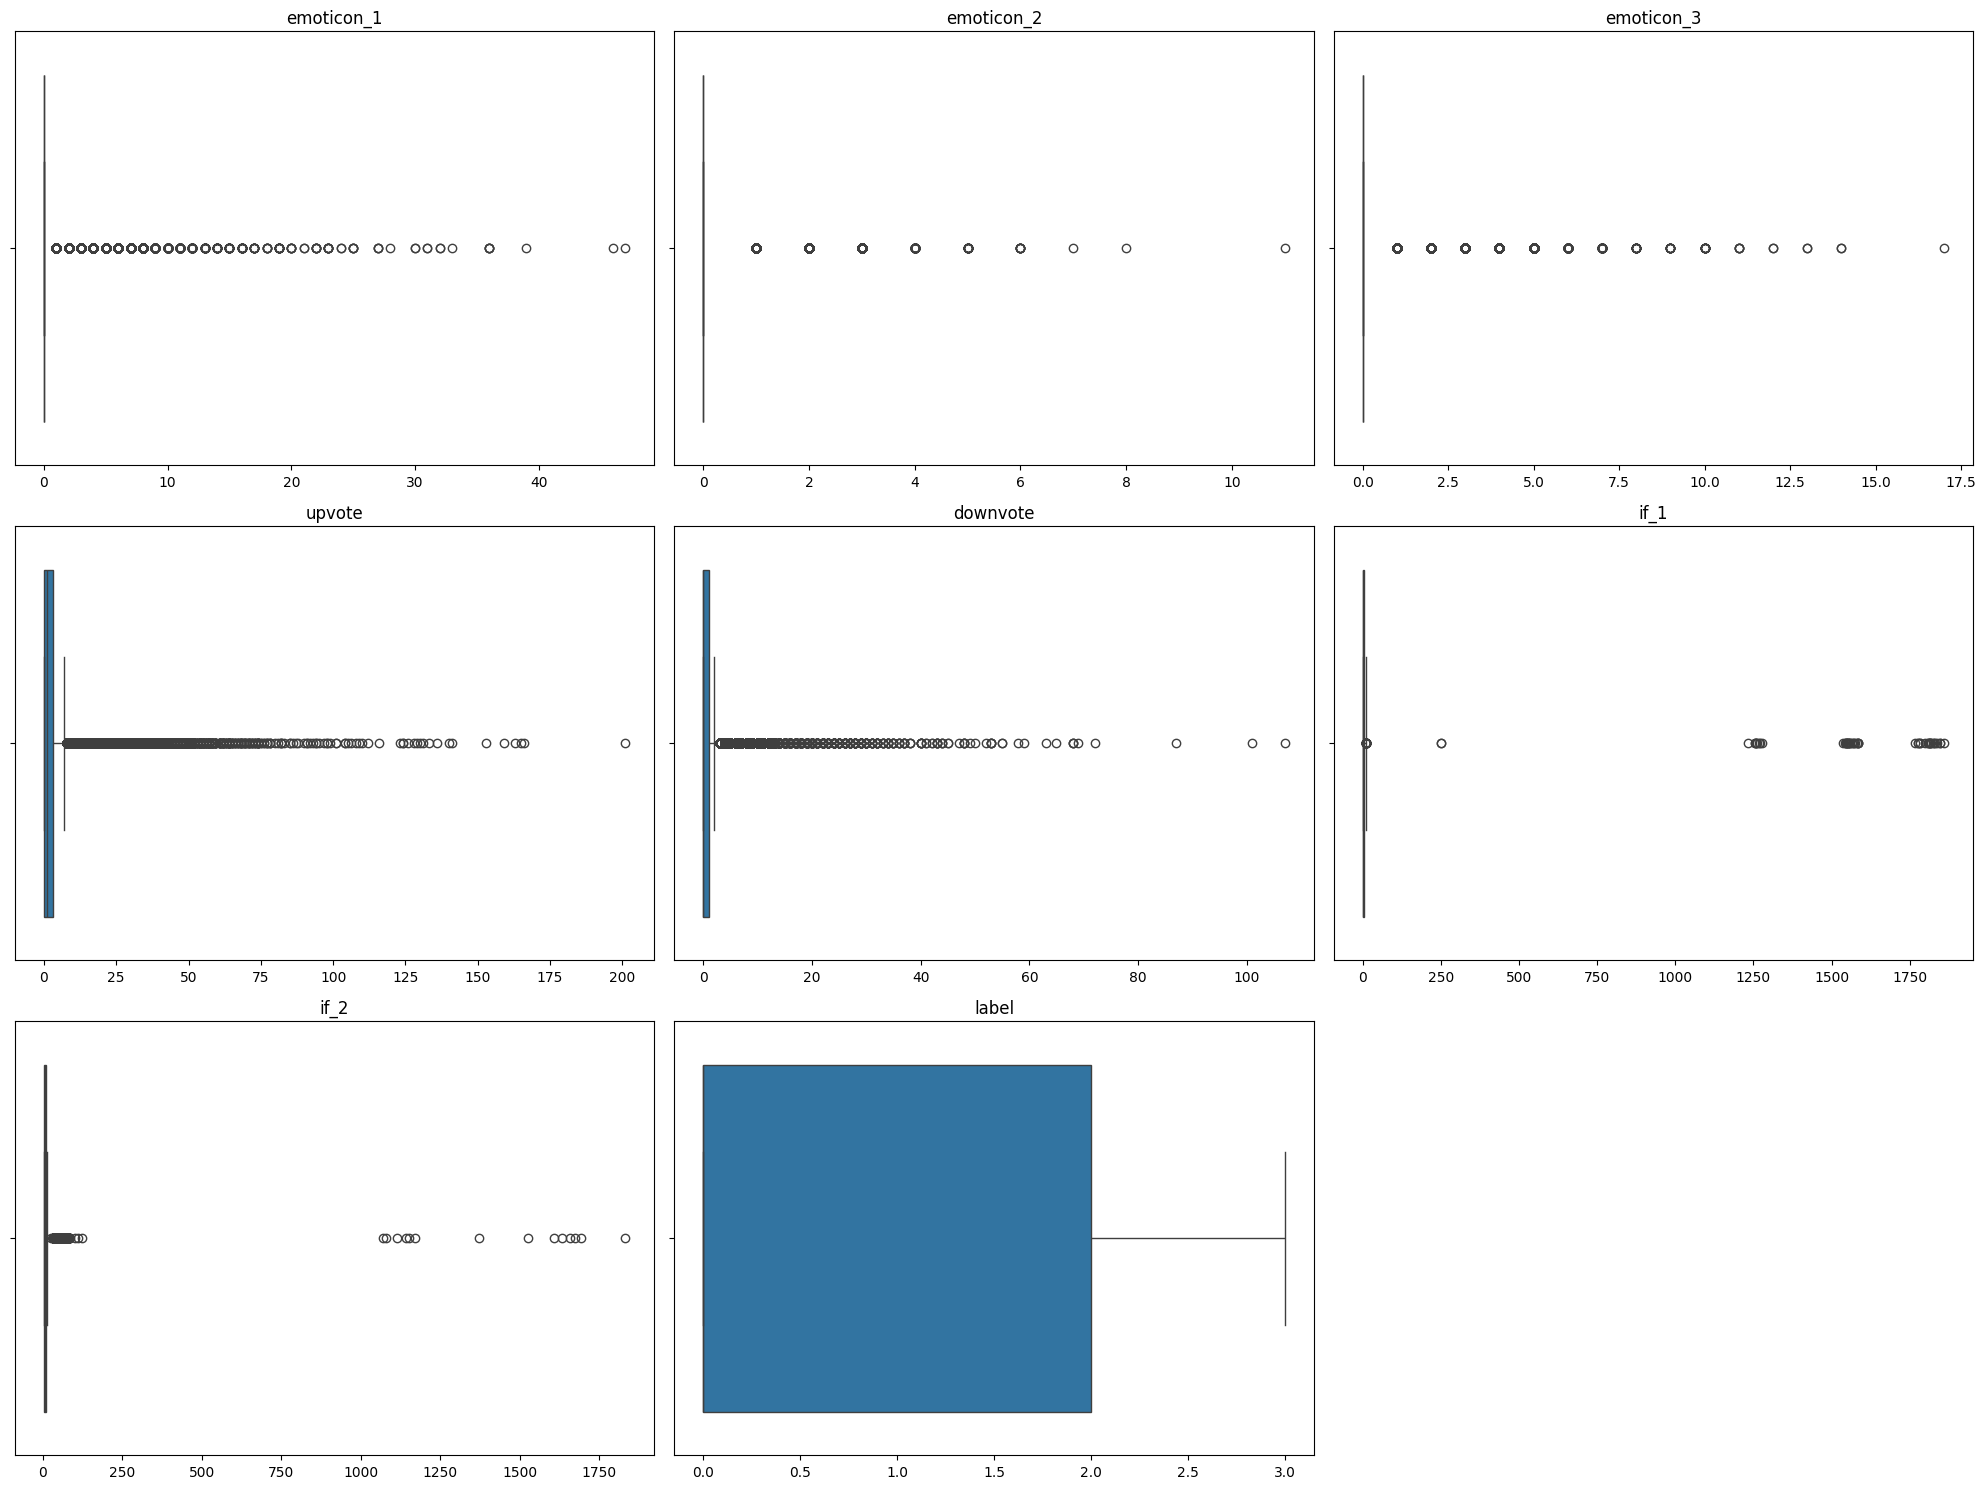

In [ ]:
n_cols = 3  # Columns per row
n_rows = (len(numerical_cols[:10]) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))

axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(numerical_cols[:10]):
    sns.boxplot(data=df_train, x=col, ax=axes[i])  # x= for horizontal boxes
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.title('Outliers detection')
plt.show()


**Insights:**


> Most features (if_2, upvote, downvote, if_1, emoticons) show extreme outliers, with the majority of values tightly clustered near zero.This confirms high skewness and presence of noisy/extreme values, which can distort model learning. Outlier handling (clipping) or log transformation would be important for better feature stability.The label boxplot again indicates discrete and imbalanced classes, consistent with earlier observations.


### Correlation Analysis

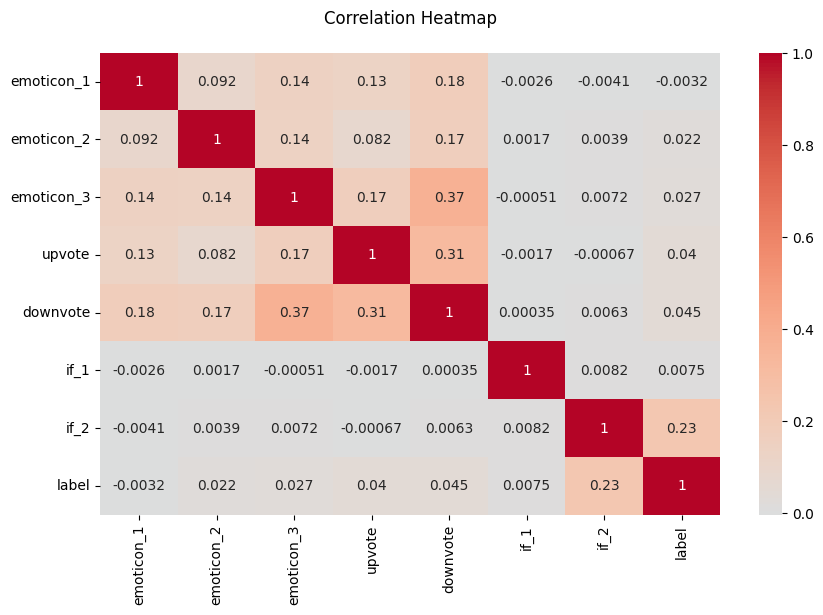

In [ ]:
corr = df_train[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Heatmap\n")
plt.show()

**Insights:**

> Most features show very weak correlation with the target (label), indicating limited linear relationship and suggesting models may need non-linear learning.Among features, downvote and emoticon_3 (0.37) and upvote–downvote (0.31) show moderate correlation, implying some interaction patterns.The only notable relation with the target is if_2 (~0.23), making it relatively more informative than other features. Overall, features are largely independent, so combining them effectively (e.g., via ensemble or complex models) is important.


### Comment length vs target Analysis

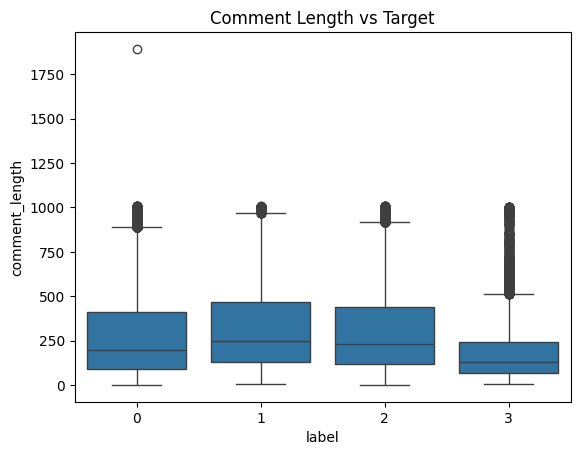

In [ ]:
df_train['comment_length'] = df_train['comment'].str.len()

sns.boxplot(x='label', y='comment_length', data=df_train)
plt.title("Comment Length vs Target")
plt.show()

**Insights:**


> Comment length varies across classes, with labels 1 and 2 having slightly higher median lengths compared to others.However, there is significant overlap between all classes, indicating weak separability using this feature alone.Class 3 tends to have shorter comments on average, while class 0 shows more variability and extreme outliers.Overall, comment length alone is not a strong predictor but may add value when combined with other features.


### Word count vs Label Analysis

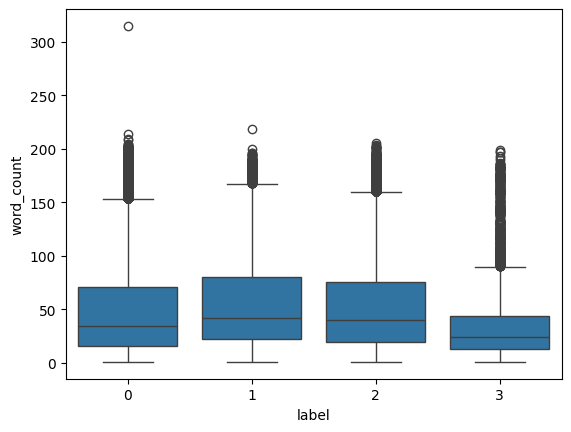

In [ ]:
df_train['word_count'] = df_train['comment'].apply(lambda x: len(str(x).split()))
df_test['word_count'] = df_test['comment'].apply(lambda x: len(str(x).split()))


sns.boxplot(x='label', y='word_count', data=df_train)
plt.show()

**Insights:**


> Word count follows a pattern similar to comment length, with labels 1 and 2 having slightly higher median values.There is heavy overlap across all classes, indicating poor class separation using this feature alone. Class 3 generally has lower word counts, while class 0 shows more spread and outliers. Overall, word count is a weak standalone feature but can still contribute when combined with others.


### Categorial columns vs Label Analysis

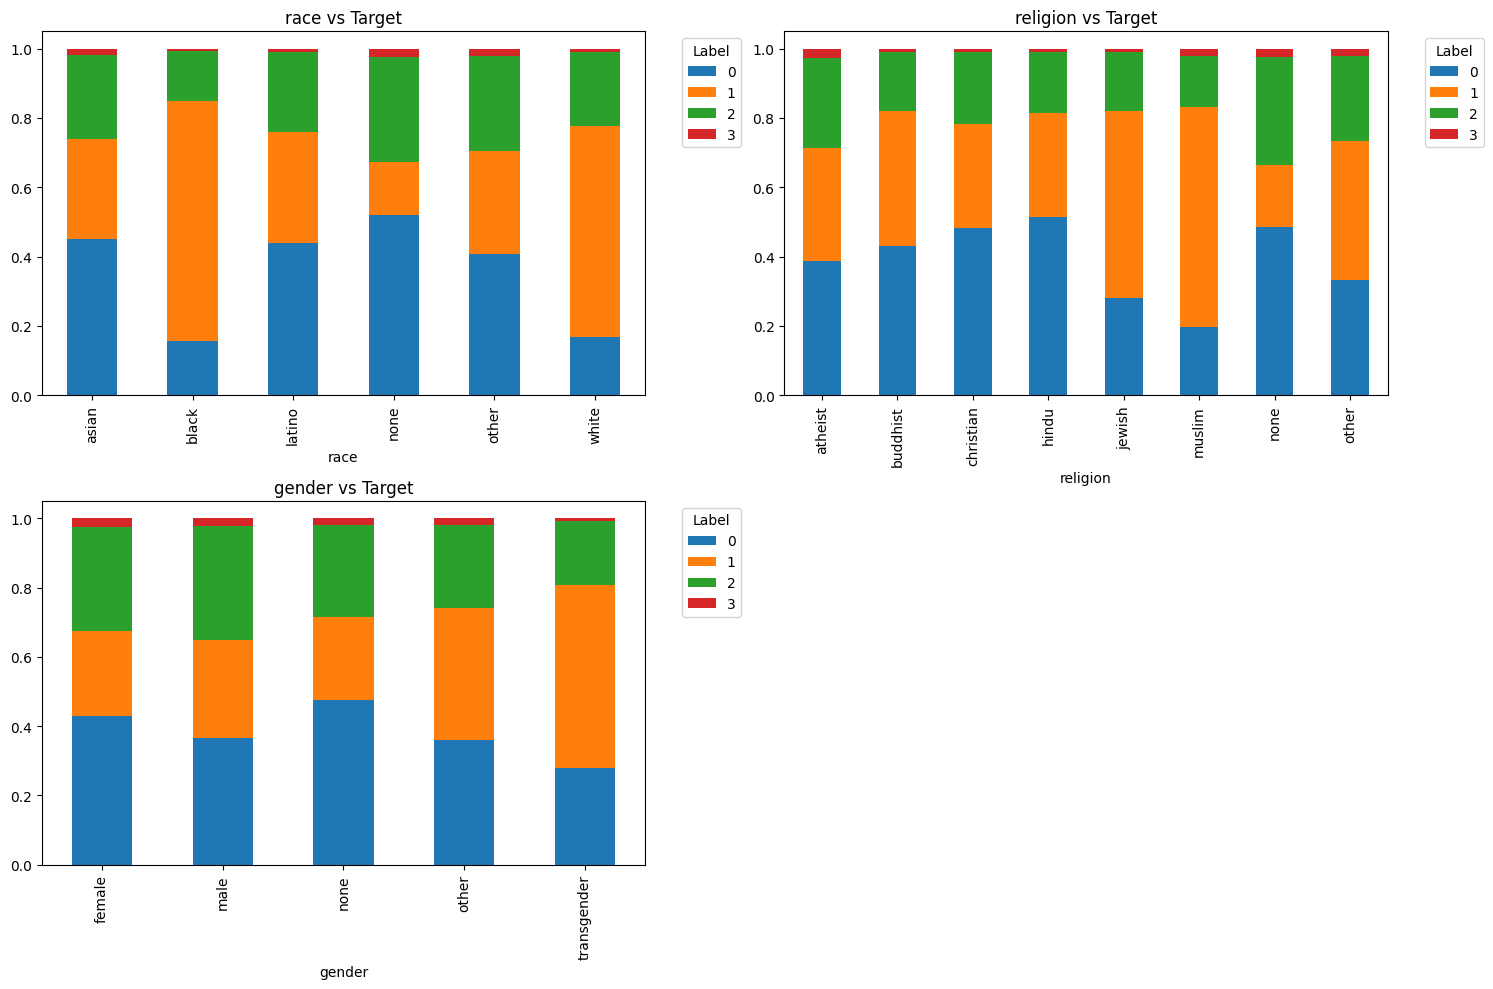

In [ ]:
cat_cols = ['race', 'religion', 'gender']
n_plots = len(cat_cols)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes]

for i, col in enumerate(cat_cols):
    crosstab = pd.crosstab(df_train[col], df_train['label'], normalize='index')
    crosstab.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f"{col} vs Target")
    axes[i].legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# Hide extras
for i in range(n_plots, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

**Insights:**


> Across categorical features (gender, race, religion), the distribution of labels varies slightly but not drastically, indicating weak direct influence on the target. Some groups (e.g., certain races or religions) show higher proportion of label 1, but patterns are not strongly consistent.Label 0 and 1 dominate across most categories, again reflecting overall class imbalance. Overall, these categorical features may add contextual value, but are not strong standalone predictors.


### Text Analysis

In [ ]:
df_train['comment'].str.len().describe()

count    197999.000000
mean        302.910893
std         266.441552
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment, dtype: float64

**Insights:**


> The average comment length is ~303 characters, with a median of 211, indicating a right-skewed distribution. There is a wide spread (std ≈ 266), showing high variability in comment lengths. The presence of very large values (max = 1892) suggests extreme outliers.Overall, most comments are relatively short, but a few very long ones significantly influence the distribution.


# Feature Engineering

In [ ]:
# converting dtype to category

cat_cols = ['race', 'religion', 'gender']
df_train[cat_cols] = df_train[cat_cols].astype('category')
df_test[cat_cols] = df_test[cat_cols].astype('category')

In [ ]:
# adding new column - comment_length

df_train['comment_length'] = df_train['comment'].str.len()
df_test['comment_length'] = df_test['comment'].str.len()

In [ ]:
# Clipping extreme comment length values at 1000 to reduce the impact of outliers

df_train['comment_length'] = df_train['comment_length'].clip(upper=1000)
df_test['comment_length'] = df_test['comment_length'].clip(upper=1000)

Result:
This helps stabilize the distribution and prevents very long comments from skewing the model

In [ ]:
df_train['comment_length']=df_train['comment_length'].fillna(0)
df_test['comment_length']=df_test['comment_length'].fillna(0)

In [ ]:
# converting comment_length dtype to int

df_train['comment_length']=df_train['comment_length'].astype(int)
df_test['comment_length']=df_test['comment_length'].astype(int)

In [ ]:
# adding new column - word count

df_train['word_count'] = df_train['comment'].apply(lambda x: len(str(x).split()))
df_test['word_count']  = df_test['comment'].apply(lambda x: len(str(x).split()))

In [ ]:
df_train=df_train.drop('post_id',axis=1)
df_test=df_test.drop('post_id',axis=1)


In [ ]:
# converting created_date col to datetime dtype

df_train['created_date'] = pd.to_datetime(df_train['created_date'])
df_test['created_date'] = pd.to_datetime(df_test['created_date'])

In [ ]:
# defining new columns from existing columns

df_train['vote_ratio'] = df_train['upvote'] / (df_train['downvote'] + 1)
df_train['engagement'] = df_train['upvote'] + df_train['downvote']

In [ ]:
df_test['vote_ratio'] = df_test['upvote'] / (df_test['downvote'] + 1)
df_test['engagement'] = df_test['upvote'] + df_test['downvote']

In [ ]:
# Creating text-based features (punctuation usage, capitalization, and word structure)
# to capture writing style, emotion, and intensity from comments, then summarizing them

for df in [df_train, df_test]:
    df['exclamation_count'] = df['comment'].fillna('').str.count('!')
    df['question_count']    = df['comment'].fillna('').str.count(r'\?')
    df['caps_ratio']        = df['comment'].fillna('').apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / (len(str(x)) + 1)
    )
    df['avg_word_length']   = df['comment'].fillna('').apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
    )

print("New features:")
print(df_train[['exclamation_count','question_count','caps_ratio','avg_word_length']].describe().round(3))

# Data Preprocessing

### Imputing Null values

In [ ]:
# imputing null values in categorical cols with 'unknown' value

from sklearn.impute import SimpleImputer

imputer=SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')

df_train[['race']]=imputer.fit_transform(df_train[['race']])
df_test[['race']]=imputer.transform(df_test[['race']])

df_train[['gender']]=imputer.fit_transform(df_train[['gender']])
df_test[['gender']]=imputer.transform(df_test[['gender']])

df_train[['religion']]=imputer.fit_transform(df_train[['religion']])
df_test[['religion']]=imputer.transform(df_test[['religion']])


In [ ]:
drop_row=df_train[df_train['comment'].isna()].index
df_train=df_train.drop(drop_row)


### Log Transformation

In [ ]:
# Applying log transformation to reduce skewness and minimize the impact of large values in upvote and downvote features

df_train['upvote'] = np.log1p(df_train['upvote'])
df_train['downvote'] = np.log1p(df_train['downvote'])

In [ ]:
df_test['upvote'] = np.log1p(df_test['upvote'])
df_test['downvote'] = np.log1p(df_test['downvote'])

In [ ]:
# Capping extreme vote_ratio values at 50 to limit the effect of outliers and stabilize the feature distribution

df_train['vote_ratio'] = df_train['vote_ratio'].clip(upper=50)
df_test['vote_ratio'] = df_test['vote_ratio'].clip(upper=50)

In [ ]:
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']

Training on full data: (197999, 23)


## Text Preprocessing

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)               # remove URLs
    text = re.sub(r"[^a-zA-Z0-9!?.,\s']", " ", text)  # keep punctuation + numbers
    text = re.sub(r"\s+", " ", text).strip()            # collapse whitespace
    return text


X_train['comment'] = X_train['comment'].apply(clean_text)
df_test['comment'] = df_test['comment'].apply(clean_text)

print("Sample cleaned comment:")
print(X_train['comment'].iloc[0])

Sample cleaned comment:
she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically challenged individuals.


### TF-IDF Vectorizer

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack


tfidf = TfidfVectorizer(
    max_features=25000,
    ngram_range=(1,2),
    sublinear_tf=True,
    stop_words=None,
    min_df=3,
    max_df=0.9
)



X_train_text = tfidf.fit_transform(X_train['comment'])
X_test_text = tfidf.transform(df_test['comment'])
print(f"TF-IDF shape: {X_train_text.shape}")


## Standard Scaling

In [ ]:
numerical_cols = X_train.select_dtypes(include=['number']).columns
numerical_cols

In [ ]:
df_test.select_dtypes(include=['number']).columns

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = X_train.select_dtypes(include=['number']).columns
X_train_num = scaler.fit_transform(X_train[numerical_cols])

# X_val_num = scaler.transform(X_val[numerical_cols])

X_test_num = scaler.transform(df_test[numerical_cols])

## Categorical Encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['race','religion','gender']

ohe = OneHotEncoder(handle_unknown='ignore')

X_train_cat = ohe.fit_transform(X_train[cat_cols])

X_test_cat = ohe.transform(df_test[cat_cols])

In [ ]:
X_train = X_train.drop(columns=cat_cols + ['comment'])


In [ ]:
X_train_extra = X_train[['comment_length','word_count']].values
X_test_extra  = df_test[['comment_length','word_count']].values


X_train_final = hstack([X_train_text, X_train_num, X_train_cat, X_train_extra])
X_test_final  = hstack([X_test_text, X_test_num, X_test_cat, X_test_extra])

# Model Training ( with Hyperparameter Tuning )

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
import lightgbm as lgb
from sklearn.metrics import f1_score

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
from sklearn.ensemble import VotingClassifier

lr_model = LogisticRegression(
    C=5, solver='liblinear', max_iter=1000, class_weight='balanced'
)

# n_estimators reduced 550→450 to save time; lr slightly raised 0.03→0.04
# to compensate — same accuracy, ~20% faster

lgbm_model = lgb.LGBMClassifier(
    n_estimators=450,
    learning_rate=0.04,
    num_leaves=128,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.1,
    class_weight='balanced',
    device='gpu',
    random_state=42,
    verbose=-1,
    n_jobs=1
)

ensemble = VotingClassifier(
    estimators=[('lr', lr_model), ('lgbm', lgbm_model)],
    voting='soft',
    weights=[1, 2]
)

print('Training on full data...')
ensemble.fit(X_train_final, y_train)
print('Done.')


# Prediction and Final Submission

In [ ]:
test_preds = ensemble.predict(X_test_final)

submission = pd.DataFrame({
    'ID'   : df_test.index + 1,
    'label': test_preds
})

submission.to_csv('submission.csv', index=False)
print('Submission Successful!!')
print(submission['label'].value_counts().sort_index())

# Milestones

## Milestone 2

Q1. In the context of text preprocessing for NLP, which condition must be checked in addition to NaN values when assessing missingness in the comment column of train.csv?

Ans. Presence of empty or whitespace-only strings

Q2. Convert the created_date column into datetime objects. Identify the month that occurs the most number of times in the dataset and enter the answer as a lowercase string

In [ ]:
df_train['created_date'] = pd.to_datetime(df_train['created_date'])
months = df_train['created_date'].dt.month_name()
months.mode()[0].lower()

Q3. Create a new feature called total_emoticons by calculating the sum of emoticon_1, emoticon_2, and emoticon_3 for each row. What is the maximum value observed in this new feature across the entire dataset?

In [ ]:
df_train['total_emoticon']=df_train['emoticon_1']+df_train['emoticon_3']+df_train['emoticon_3']
df_train['total_emoticon'].max()

Q4. Calculate the median character length (including spaces) of the comment column for all entries where label is equal to 3. (Note: Treat any missing comments as empty strings).

In [ ]:
def comment_len(s):
    return len(s)

comment_length = (df_train[df_train['label']==3]['comment']).apply(comment_len)
print(comment_length.median())

Q5. If you apply Min-Max Scaling to the upvote column to normalize it between the range [0, 1], what would be the resulting scaled value for an observation that originally had exactly 10 upvotes?

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_train['scaled_upvote'] = scaler.fit_transform(df_train[['upvote']])

df_train.loc[df_train['upvote']==10]['scaled_upvote']

Q6. What is the average word count (number of words separated by whitespace) for comments that are assigned a label of 1? (Round your answer to 2 decimal places).

In [ ]:
def word_count(s):
    return len(str(s).split())

df_train['word_count']=df_train['comment'].apply(word_count)
df_train[df_train['label']==1]['word_count']).mean().round(2)

Q7. How many comments in the entire dataset contain the substring "Trump"? The search should be case-insensitive.

In [ ]:
df_train[df_train['comment'].str.contains('Trump',case=False)==True]['post_id'].count()

Q8. Take the comment at the very first row (index 0).

- Remove all punctuation.

- Consider the following words as stop words and remove the same :  ['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for', 'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it', 'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which', 'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']
How many words are left in the text after these two operations?

In [ ]:
df_train['comment'][0]
import string

text = df_train['comment'][0]
clean_text = ''.join([char for char in text if char not in string.punctuation])
clean_text

word_list=['a', 'an', 'the', 'and', 'or', 'but', 'if', 'because', 'as', 'of', 'at', 'by', 'for',
           'with', 'about', 'to', 'from', 'up', 'on', 'in', 'out', 'over', 'under', 'is', 'are',
           'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'do', 'does', 'did', 'it',
           'its', 'they', 'them', 'their', 'she', 'her', 'he', 'him', 'his', 'this', 'that', 'which',
           'who', 'whom', 'i', 'me', 'my', 'we', 'our', 'you', 'your']

words=clean_text.split(' ')
count=0
for word in word_list:
    if word in words:
        count+=1

print(len(clean_text.split(' '))-count)

Q9. Convert all the text in comment column to lowercase and tokenizing using whitespace. Compute the total number of unique tokens in the dataset and enter the value

In [ ]:
tokens_series = df_train['comment'].str.lower().str.split()

all_tokens = set()
for tokens in tokens_series.dropna():
    all_tokens.update(tokens)

unique_token_count = len(all_tokens)
print(f"Total number of unique tokens: {unique_token_count}")

Q10. Apply the TfidfVectorizer to the comment column of train.csv with stop_words as "english", min_df as 5 and ngram_range as (1,2).

How many TF-IDF features are generated using this configuration?

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_test['comment'] = df_test['comment'].fillna('')
tfidf = TfidfVectorizer(
    stop_words='english',
    min_df=5,
    ngram_range=(1, 2))

tfidf_matrix = tfidf.fit_transform(df_test['comment'])
num_features = len(tfidf.get_feature_names_out())
print(f"Total features generated: {num_features}")

## Milestone 3

Q1. Split the train dataset using train_test_split with random_state=42 such that 80% is training data and remaining 20% is validation data. store the data as X_train, X_val, y_train, y_val. Lets say training data (X_train) has shape (a,b) where a is number of rows and b is the number of features, similarly validation set (X_val) has shape (c,d) where c is the number of rows and d is the number of features. what will be the value of a + c ?

In [ ]:
from sklearn.model_selection import train_test_split
X=df_train.drop('label',axis=1)
y=df_train['label']

X_train,X_val,y_train,y_val= train_test_split(X,y,test_size=0.2,random_state=42)
a=X_train.shape[0]
c=X_val.shape[0]
print('Value of a+c: ',a+c)

Q2. After converting created_date to a datetime object and extracting the day, month, and year for your X_train and X_val created in the first question, identify the most frequently occurring month across all years in X_train. Which month is it?

In [ ]:
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
months = X_train['created_date'].dt.month_name()
print('Most frequently occurring month across all years in X_train: ',months.mode()[0])

Q3. Impute the null values of categorical features with the value 'none'. Encode only religion', 'gender', 'race' features using one hot encoding, setting handle_unknown='ignore'. Make sure the output is a pandas dataframe. Let's say the shape of X_train after imputing is (a,b), what is the value of b ? Note: make sure to transform X_val as well using one hot encoding.

In [ ]:
import numpy as np
from sklearn.impute import SimpleImputer

cat_cols_train = X_train.select_dtypes(include=['object']).columns
cat_cols_val = X_val.select_dtypes(include=['object']).columns

imputer = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='none')
X_train[cat_cols_train] = imputer.fit_transform(X_train[cat_cols_train])
X_val[cat_cols_val] = imputer.transform(X_val[cat_cols_val])

from sklearn.preprocessing import OneHotEncoder
cols= ['religion', 'gender', 'race']
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[cols])
X_val_ohe   = ohe.transform(X_val[cols])

ohe_cols = ohe.get_feature_names_out(cols)
X_train_ohe_df = pd.DataFrame(X_train_ohe, columns=ohe_cols, index=X_train.index)
X_val_ohe_df   = pd.DataFrame(X_val_ohe, columns=ohe_cols, index=X_val.index)
other_cols = [c for c in X_train.columns if c not in cols]
X_train_final = pd.concat([X_train[other_cols], X_train_ohe_df], axis=1)
X_val_final   = pd.concat([X_val[other_cols],   X_val_ohe_df],   axis=1)

a, b = X_train_final.shape
print("b =", b)

Q4. Apply CountVectorizer to the column comment of X_train and X_val obtained in previous questions, what is the sum of the counts for the document at index 1 (the second row) of the transformed X_train sparse matrix? Note: Please ensure to transform X_val as well.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_train_sparse = vectorizer.fit_transform(X_train_final['comment'])
X_val_sparse   = vectorizer.transform(X_val_final['comment'])

# Sum of counts for document at index 1 (second row)
row_sum = X_train_sparse[1].sum()

print("Sum for index 1:", row_sum)

Q5. Convert 'disability' feature into integer type, with True being mapped to 1 and False mapped to 0. What is the sum of all the 'disability values in X_train and X_val after the transformation?

In [ ]:
X_train_final['disability'] = X_train_final['disability'].astype(int)
X_val_final['disability']   = X_val_final['disability'].astype(int)
total_sum = X_train_final['disability'].sum() + X_val_final['disability'].sum()
print("Total sum:", total_sum)

Q6. Scale the numeric features using StandardScaler. What are the number of features seen during fit for X_train? Ensure that you drop all datetime columns first.

In [ ]:
from sklearn.preprocessing import StandardScaler

datetime_cols = X_train_final.select_dtypes(include=['datetime64', 'datetime64[ns]']).columns
X_train_final = X_train_final.drop(columns=datetime_cols)
X_val_final   = X_val_final.drop(columns=datetime_cols)

num_cols = X_train_final.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train_final[num_cols] = scaler.fit_transform(X_train_final[num_cols])
X_val_final[num_cols]   = scaler.transform(X_val_final[num_cols])

num_features = scaler.n_features_in_

print("Number of features:", num_features)

Q7. Preprocess the data in the following manner and train the model:

0) Use the full raw data and first split it into training and validation sets so that 80% of the data forms X_train, y_train and the remaining 20% forms X_val, y_val.

After splitting:

Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid strategy for Imputation.

Use the fitted imputer to transform both X_train and X_val

Ensure that after imputation no value in X_train or X_val is negative.

If any negative value exists, convert it to positive using the absolute value function

1) Convert the created_date feature into a datetime object and engineer three new numerical features: day, month, and year. keep these three new features and drop the feature created_date. Make sure to transform X_val accordingly.

2) Transform the "comment" feature using TfidfVectorizer with stop_words='english'. Make sure to transform X_val accordingly.

3) Encode all the categorical features using one hot encoder with handle_unknown='ignore'. Make sure to transform X_val accordingly. Now train a Multinomial Naive Bayes model on the preprocessed data. Use a pipeline if you need to. What is the macro F1 score obtained on the train dataset?

Note: you may train Multinomial Naive Bayes model on the preprocessed data which has been obtained from previous questions and give the answer, both ways the answers will be accepted.

If some feature is creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc).

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


df_raw= pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X_raw = df_raw.drop('label', axis=1)
y_raw = df_raw['label']
X_train, X_val, y_train, y_val = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

# Imputation (median for numeric, constant 'none' for cat to avoid negatives)
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='constant', fill_value='none')

X_train[num_cols] = imputer_num.fit_transform(X_train[num_cols])
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])

X_val[num_cols] = imputer_num.transform(X_val[num_cols])
X_val[cat_cols] = imputer_cat.transform(X_val[cat_cols])

X_train[num_cols] = np.abs(X_train[num_cols])
X_val[num_cols] = np.abs(X_val[num_cols])

# 1. Date engineering
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])

for df in [X_train, X_val]:
    df['day'] = df['created_date'].dt.day
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year
    df = df.drop('created_date', axis=1)

# Update cols
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.drop('comment', errors='ignore')

# 2) TF-IDF on comment
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train['comment'])
X_val_tfidf = tfidf.transform(X_val['comment'])

# 3) One-hot categorical
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[cat_cols])
X_val_ohe = ohe.transform(X_val[cat_cols])

In [ ]:
from scipy.sparse import hstack
X_train_final = hstack([X_train[num_cols].values, X_train_tfidf, X_train_ohe])
X_val_final = hstack([X_val[num_cols].values, X_val_tfidf, X_val_ohe])

nb = MultinomialNB()
nb.fit(X_train_final, y_train)

train_pred = nb.predict(X_train_final)
macro_f1_train = f1_score(y_train, train_pred, average='macro')

print("Macro F1 train:", macro_f1_train)

Q8. What is the macro F1 score obtained on the validation dataset?

In [ ]:
val_pred = nb.predict(X_val_final)
macro_f1_val = f1_score(y_val, val_pred, average='macro')

print("Macro F1 validation:", macro_f1_val)

Q9. Process the data in the following manner as given below and train the model. 0) Use the full raw data and first split it into training and validation sets so that 80% of the data forms X_train, y_train and the remaining 20% forms X_val, y_val. After splitting:

Impute missing values by fitting the SimpleImputer on X_train. You are free to use any valid strategy for Imputation.

Use the fitted imputer to transform both X_train and X_val

Ensure that after imputation no value in X_train or X_val is negative.

If any negative value exists, convert it to positive using the absolute value function

1) Convert the created_date feature into a datetime object and engineer three new numerical features: day, month, and year. keep these three new features and drop the feature created_date. Make sure to transform X_val accordingly.

2) Create a new binary categorical column named is_weekend where Saturday and Sunday are represented as 1 and all other days as 0.

3) Apply TfidfVectorizer(stop_words='english') to the comment column. Make sure to transform X_val accordingly.

4) Apply OneHotEncoder(handle_unknown='ignore') to the categorical features including newly created categorical feature is_weekend. Make sure to transform X_val accordingly.

After all above transformation, train MultinomialNB model.

After training, use the model to predict the labels for X_train and calculate the Macro F1 score. What is the resulting score rounded to four decimal places?

note: If some features are creating problem or giving error during fit, you can find a way to handle it such as (dropping it, encoding it, changing its data type etc).

In [ ]:
from scipy.sparse import csr_matrix

df_raw= pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
X_raw = df_raw.drop('label', axis=1)
y_raw = df_raw['label']
X_train, X_val, y_train, y_val = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)

num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='constant', fill_value='none')

X_train[num_cols] = np.abs(imputer_num.fit_transform(X_train[num_cols]))
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
X_val[num_cols] = np.abs(imputer_num.transform(X_val[num_cols]))
X_val[cat_cols] = imputer_cat.transform(X_val[cat_cols])

# 1) Date engineering
X_train['created_date'] = pd.to_datetime(X_train['created_date'])
X_val['created_date'] = pd.to_datetime(X_val['created_date'])

for df in [X_train, X_val]:
    df['day'] = df['created_date'].dt.day
    df['month'] = df['created_date'].dt.month
    df['year'] = df['created_date'].dt.year
    df['is_weekend'] = df['created_date'].dt.dayofweek.isin([5,6]).astype(int)
    df.drop('created_date', axis=1, inplace=True)

# Updating columns after engineering
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(include=['object']).columns
text_col = 'comment'

# 3) TF-IDF on comment
tfidf = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train[text_col])
X_val_tfidf = tfidf.transform(X_val[text_col])

cat_cols_no_text = [c for c in cat_cols if c != text_col]
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = ohe.fit_transform(X_train[cat_cols_no_text])
X_val_ohe = ohe.transform(X_val[cat_cols_no_text])

X_train_final = hstack([
    csr_matrix(X_train[num_cols].values),  # sparse numeric
    X_train_tfidf,
    csr_matrix(X_train_ohe)                # sparse ohe
])
X_val_final = hstack([
    csr_matrix(X_val[num_cols].values),
    X_val_tfidf,
    csr_matrix(X_val_ohe)
])

# Train and predict train
nb = MultinomialNB()
nb.fit(X_train_final, y_train)
train_pred = nb.predict(X_train_final)
macro_f1 = f1_score(y_train, train_pred, average='macro')

print(f"Macro F1 train (rounded to 4 decimals): {macro_f1:.4f}")

Q10. What is the macro F1-score on validation set for the previous question's setup?

In [ ]:
al_pred = nb.predict(X_val_final)
macro_f1_val = f1_score(y_val, val_pred, average='macro')
print(f"Macro F1 validation (4 decimals): {macro_f1_val:.4f}")